# Real Time Angle Detector

This notebook refactors the legacy angle detector into a notebook-first classical computer vision project built on the real Kaggle geometric shapes dataset.

## Why OpenCV is the correct method
- The task is geometric angle measurement, not learned recognition.
- The dataset contains clean shape images with labeled folders for Circle, Square, and Triangle.
- OpenCV contour extraction plus polygon approximation is enough to recover vertices and estimate interior angles honestly.

## Dataset source
- Kaggle: https://www.kaggle.com/datasets/dineshpiyasamara/geometric-shapes-dataset
- The source dataset does not ship with train/validation/test splits. This notebook verifies that fact and performs deterministic per-class analysis instead of inventing a split.

In [1]:
from pathlib import Path
import importlib
import json

required_packages = {
    'kagglehub': 'kagglehub',
    'opencv-python': 'cv2',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib'
}

for package_name, module_name in required_packages.items():
    importlib.import_module(module_name)
    print(f'\u2713 {package_name}')

BASE_DIR = Path.home() / 'real_time_angle_detector_project'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'\nBase directory: {BASE_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ kagglehub
✓ opencv-python
✓ numpy
✓ pandas
✓ matplotlib

Base directory: C:\Users\ahmad\real_time_angle_detector_project
Output directory: C:\Users\ahmad\real_time_angle_detector_project\outputs


In [2]:
import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

EXPECTED_LABELS = ['Circle', 'Square', 'Triangle']
IMAGE_SUFFIXES = {'.png', '.jpg', '.jpeg'}
MAX_IMAGES_PER_CLASS = 40
SEED = 42
np.random.seed(SEED)

## Dataset Download And Verification

The next cell downloads the Kaggle dataset in real notebook code, checks the actual folder layout, counts files per class, and explicitly records that there is no predefined split structure in the source.

In [3]:
download_root = Path(kagglehub.dataset_download('dineshpiyasamara/geometric-shapes-dataset'))
dataset_dir = download_root / 'geometric shapes dataset'

if not dataset_dir.exists():
    raise FileNotFoundError(f'Expected dataset folder was not found: {dataset_dir}')

class_dirs = [path for path in sorted(dataset_dir.iterdir()) if path.is_dir()]
class_names = [path.name for path in class_dirs]
if class_names != EXPECTED_LABELS:
    raise ValueError(f'Unexpected class folders: {class_names}')

dataset_rows = []
for class_dir in class_dirs:
    image_paths = [path for path in sorted(class_dir.iterdir()) if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES]
    if not image_paths:
        raise ValueError(f'No images found in {class_dir}')
    dataset_rows.append({
        'label': class_dir.name,
        'image_count': len(image_paths),
        'first_file': image_paths[0].name,
        'split_note': 'No split folders provided by source dataset'
    })

dataset_summary_df = pd.DataFrame(dataset_rows)
print(f'Dataset root: {dataset_dir}')
display(dataset_summary_df)

Dataset root: C:\Users\ahmad\.cache\kagglehub\datasets\dineshpiyasamara\geometric-shapes-dataset\versions\1\geometric shapes dataset


,label,image_count,first_file,split_note
0,Circle,10000,Circle_000dfc5c-2a92-11ea-8123-8363a7ec19e6.png,No split folders provided by source dataset
1,Square,10000,Square_00038fb0-2a97-11ea-8123-8363a7ec19e6.png,No split folders provided by source dataset
2,Triangle,10000,Triangle_0002bd26-2a9a-11ea-8123-8363a7ec19e6.png,No split folders provided by source dataset


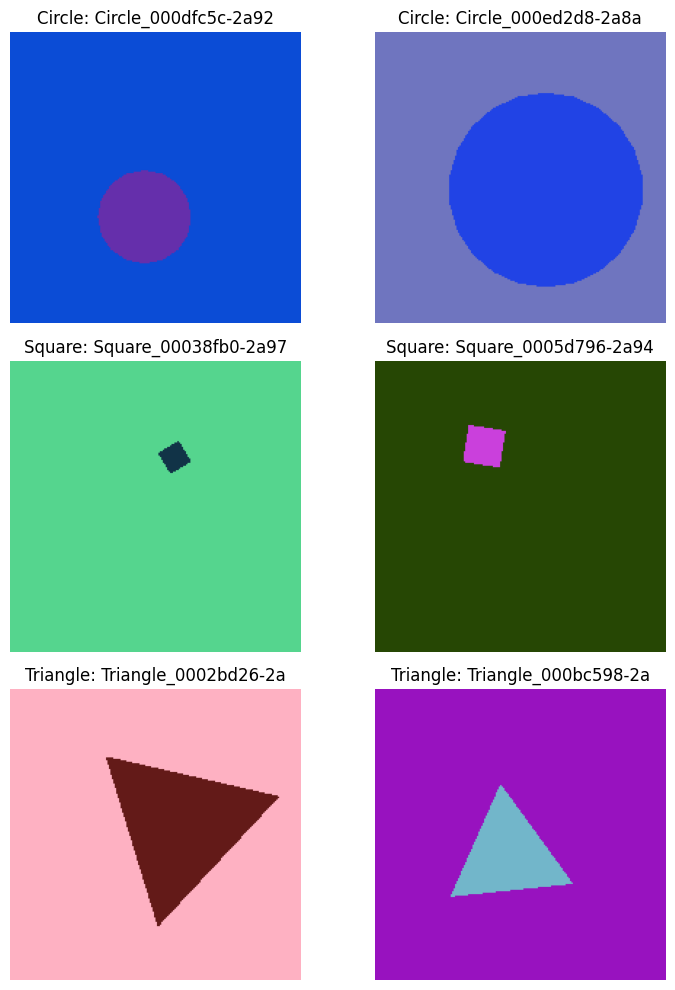

✓ Dataset overview saved to C:\Users\ahmad\real_time_angle_detector_project\outputs\dataset_overview.png


In [4]:
sample_rows = []
for label in EXPECTED_LABELS:
    class_dir = dataset_dir / label
    image_paths = [path for path in sorted(class_dir.iterdir()) if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES]
    sample_rows.extend([(label, image_paths[0]), (label, image_paths[1])])

fig, axes = plt.subplots(len(EXPECTED_LABELS), 2, figsize=(8, 10))
for axis, sample_row in zip(axes.flat, sample_rows):
    label, image_path = sample_row
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    axis.imshow(image_rgb)
    axis.set_title(f'{label}: {image_path.name[:20]}')
    axis.axis('off')

plt.tight_layout()
dataset_overview_path = OUTPUT_DIR / 'dataset_overview.png'
fig.savefig(dataset_overview_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Dataset overview saved to {dataset_overview_path}')

## Geometry Pipeline

The legacy script measured an angle from three clicked points. This notebook moves the controlling logic to the real image geometry: threshold the shape, find the largest contour, approximate the polygon, and compute interior angles from the recovered vertices.

In [5]:
def prepare_binary_mask(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return gray, binary


def largest_contour(binary_mask):
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    return max(contours, key=cv2.contourArea)


def sort_vertices_clockwise(vertices):
    center = vertices.mean(axis=0)
    polar_angles = np.arctan2(vertices[:, 1] - center[1], vertices[:, 0] - center[0])
    order = np.argsort(polar_angles)
    return vertices[order]


def compute_interior_angles(vertices):
    ordered = sort_vertices_clockwise(vertices.astype(np.float32))
    previous_vertices = np.roll(ordered, 1, axis=0)
    next_vertices = np.roll(ordered, -1, axis=0)
    incoming = previous_vertices - ordered
    outgoing = next_vertices - ordered
    denominator = np.linalg.norm(incoming, axis=1) * np.linalg.norm(outgoing, axis=1)
    denominator = np.clip(denominator, 1e-8, None)
    cosine_values = np.sum(incoming * outgoing, axis=1) / denominator
    cosine_values = np.clip(cosine_values, -1.0, 1.0)
    return np.degrees(np.arccos(cosine_values))


def analyze_shape_image(image_path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        return {'status': 'read_error', 'image_path': str(image_path)}

    gray, binary = prepare_binary_mask(image_bgr)
    contour = largest_contour(binary)
    if contour is None:
        return {'status': 'no_contour', 'image_path': str(image_path)}

    area = float(cv2.contourArea(contour))
    perimeter = float(cv2.arcLength(contour, True))
    if area <= 0 or perimeter <= 0:
        return {'status': 'degenerate_contour', 'image_path': str(image_path)}

    epsilon = 0.02 * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    vertices = approx.reshape(-1, 2)
    circularity = float((4 * np.pi * area) / (perimeter ** 2))

    if len(vertices) >= 3 and len(vertices) <= 8:
        interior_angles = compute_interior_angles(vertices)
    else:
        interior_angles = np.array([])

    annotated = image_bgr.copy()
    cv2.drawContours(annotated, [approx], -1, (0, 255, 0), 2)
    for vertex in vertices:
        cv2.circle(annotated, tuple(vertex), 5, (255, 0, 0), -1)

    note = f'vertices={len(vertices)} circularity={circularity:.3f}'
    cv2.putText(annotated, note, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2)

    if interior_angles.size > 0:
        angle_text = ', '.join(f'{value:.1f}' for value in interior_angles[:4])
        cv2.putText(annotated, angle_text, (10, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

    return {
        'status': 'ok',
        'image_path': str(image_path),
        'image_name': image_path.name,
        'vertex_count': int(len(vertices)),
        'contour_area': area,
        'perimeter': perimeter,
        'circularity': circularity,
        'angle_count': int(interior_angles.size),
        'angle_mean_deg': float(interior_angles.mean()) if interior_angles.size > 0 else np.nan,
        'angle_sum_deg': float(interior_angles.sum()) if interior_angles.size > 0 else np.nan,
        'angles_deg': [float(value) for value in interior_angles],
        'annotated_rgb': cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    }

In [6]:
analysis_records = []
example_results = []

for label in EXPECTED_LABELS:
    class_dir = dataset_dir / label
    image_paths = [path for path in sorted(class_dir.iterdir()) if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES]
    selected_paths = image_paths[:MAX_IMAGES_PER_CLASS]
    for image_path in selected_paths:
        result = analyze_shape_image(image_path)
        result['label'] = label
        if label == 'Triangle':
            result['expected_structure'] = '3 vertices and angle sum close to 180 degrees'
            result['structure_match'] = result.get('vertex_count') == 3
            result['angle_error_deg'] = abs(result.get('angle_sum_deg', np.nan) - 180.0) if result.get('vertex_count') == 3 else np.nan
        elif label == 'Square':
            result['expected_structure'] = '4 vertices and mean angle close to 90 degrees'
            result['structure_match'] = result.get('vertex_count') == 4
            result['angle_error_deg'] = abs(result.get('angle_mean_deg', np.nan) - 90.0) if result.get('vertex_count') == 4 else np.nan
        else:
            result['expected_structure'] = 'Circle-like contour with no polygon angle claim'
            result['structure_match'] = bool(result.get('circularity', 0.0) >= 0.8 and result.get('vertex_count', 0) > 4)
            result['angle_error_deg'] = np.nan

        analysis_records.append({
            'label': result['label'],
            'image_name': result.get('image_name', Path(result['image_path']).name),
            'status': result['status'],
            'vertex_count': result.get('vertex_count', np.nan),
            'circularity': result.get('circularity', np.nan),
            'angle_count': result.get('angle_count', np.nan),
            'angle_mean_deg': result.get('angle_mean_deg', np.nan),
            'angle_sum_deg': result.get('angle_sum_deg', np.nan),
            'structure_match': result['structure_match'],
            'angle_error_deg': result['angle_error_deg'],
            'expected_structure': result['expected_structure']
        })

        if result['status'] == 'ok' and len([item for item in example_results if item['label'] == label]) < 2:
            example_results.append(result)

analysis_df = pd.DataFrame(analysis_records)
summary_df = analysis_df.groupby('label', as_index=False).agg(
    images_analyzed=('image_name', 'count'),
    structure_match_rate=('structure_match', 'mean'),
    median_vertex_count=('vertex_count', 'median'),
    mean_circularity=('circularity', 'mean'),
    mean_angle_error_deg=('angle_error_deg', 'mean')
)

display(summary_df)

,label,images_analyzed,structure_match_rate,median_vertex_count,mean_circularity,mean_angle_error_deg
0,Circle,40,0.425,4.0,0.832349,NaN
1,Square,40,0.975,4.0,0.750466,0.000001
2,Triangle,40,0.550,3.0,0.661476,0.000008


## Evaluation

This is an honest geometry audit rather than a train/test benchmark. For triangles we check whether the detected polygon has 3 vertices and whether the interior angle sum is near 180 degrees. For squares we check for 4 vertices and a mean interior angle near 90 degrees. For circles we check whether the method abstains from a polygon claim by treating the contour as circle-like.

,label,image_name,status,vertex_count,circularity,angle_count,angle_mean_deg,angle_sum_deg,structure_match,angle_error_deg,expected_structure
0,Circle,Circle_000dfc5c-2a92-11ea-8123-8363a7ec19e6.png,ok,4.0,0.785398,4.0,90.000000,360.000000,False,NaN,Circle-like contour with no polygon angle claim
1,Circle,Circle_000ed2d8-2a8a-11ea-8123-8363a7ec19e6.png,ok,8.0,0.894513,8.0,135.000000,1080.000000,True,NaN,Circle-like contour with no polygon angle claim
2,Circle,Circle_0013f29e-2a9a-11ea-8123-8363a7ec19e6.png,ok,8.0,0.893651,8.0,135.000000,1080.000000,True,NaN,Circle-like contour with no polygon angle claim
3,Circle,Circle_001d7284-2a85-11ea-8123-8363a7ec19e6.png,ok,4.0,0.785398,4.0,90.000000,360.000000,False,NaN,Circle-like contour with no polygon angle claim
4,Circle,Circle_001de166-2a89-11ea-8123-8363a7ec19e6.png,ok,4.0,0.785398,4.0,90.000000,360.000000,False,NaN,Circle-like contour with no polygon angle claim
5,Circle,Circle_001f0442-2a8e-11ea-8123-8363a7ec19e6.png,ok,4.0,0.785398,4.0,90.000000,360.000000,False,NaN,Circle-like contour with no polygon angle claim
6,Circle,Circle_002bf074-2a95-11ea-8123-8363a7ec19e6.png,ok,8.0,0.888814,8.0,135.000000,1080.000000,True,NaN,Circle-like contour with no polygon angle claim
7,Circle,Circle_0035a8ac-2a91-11ea-8123-8363a7ec19e6.png,ok,8.0,0.895202,8.0,134.999985,1079.999878,True,NaN,Circle-like contour with no polygon angle claim
8,Circle,Circle_003fd9dc-2a99-11ea-8123-8363a7ec19e6.png,ok,4.0,0.785398,4.0,90.000000,360.000000,False,NaN,Circle-like contour with no polygon angle claim
9,Circle,Circle_004542ae-2a86-11ea-8123-8363a7ec19e6.png,ok,8.0,0.894775,8.0,135.000000,1080.000000,True,NaN,Circle-like contour with no polygon angle claim


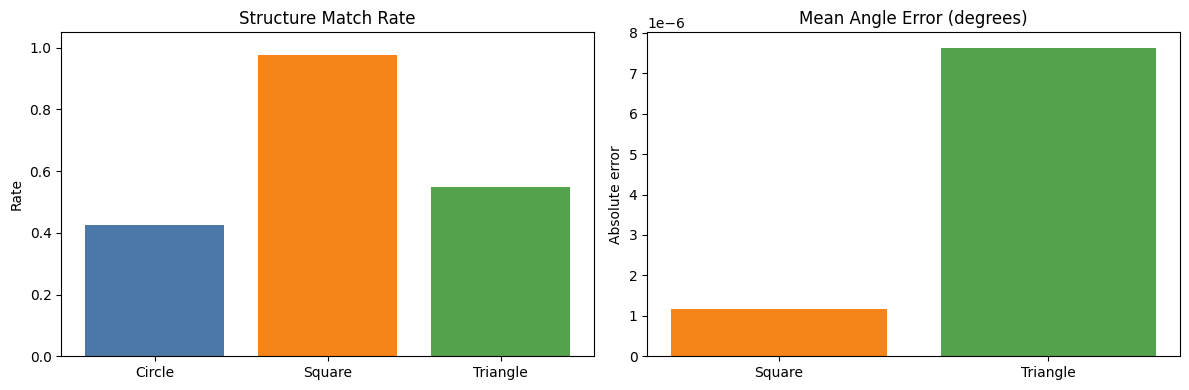

✓ Metrics plot saved to C:\Users\ahmad\real_time_angle_detector_project\outputs\angle_detector_metrics.png


In [7]:
display(analysis_df.head(12))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(summary_df['label'], summary_df['structure_match_rate'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Structure Match Rate')
axes[0].set_ylabel('Rate')

error_subset = summary_df[summary_df['mean_angle_error_deg'].notna()]
axes[1].bar(error_subset['label'], error_subset['mean_angle_error_deg'], color=['#f58518', '#54a24b'])
axes[1].set_title('Mean Angle Error (degrees)')
axes[1].set_ylabel('Absolute error')

plt.tight_layout()
metrics_plot_path = OUTPUT_DIR / 'angle_detector_metrics.png'
fig.savefig(metrics_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Metrics plot saved to {metrics_plot_path}')

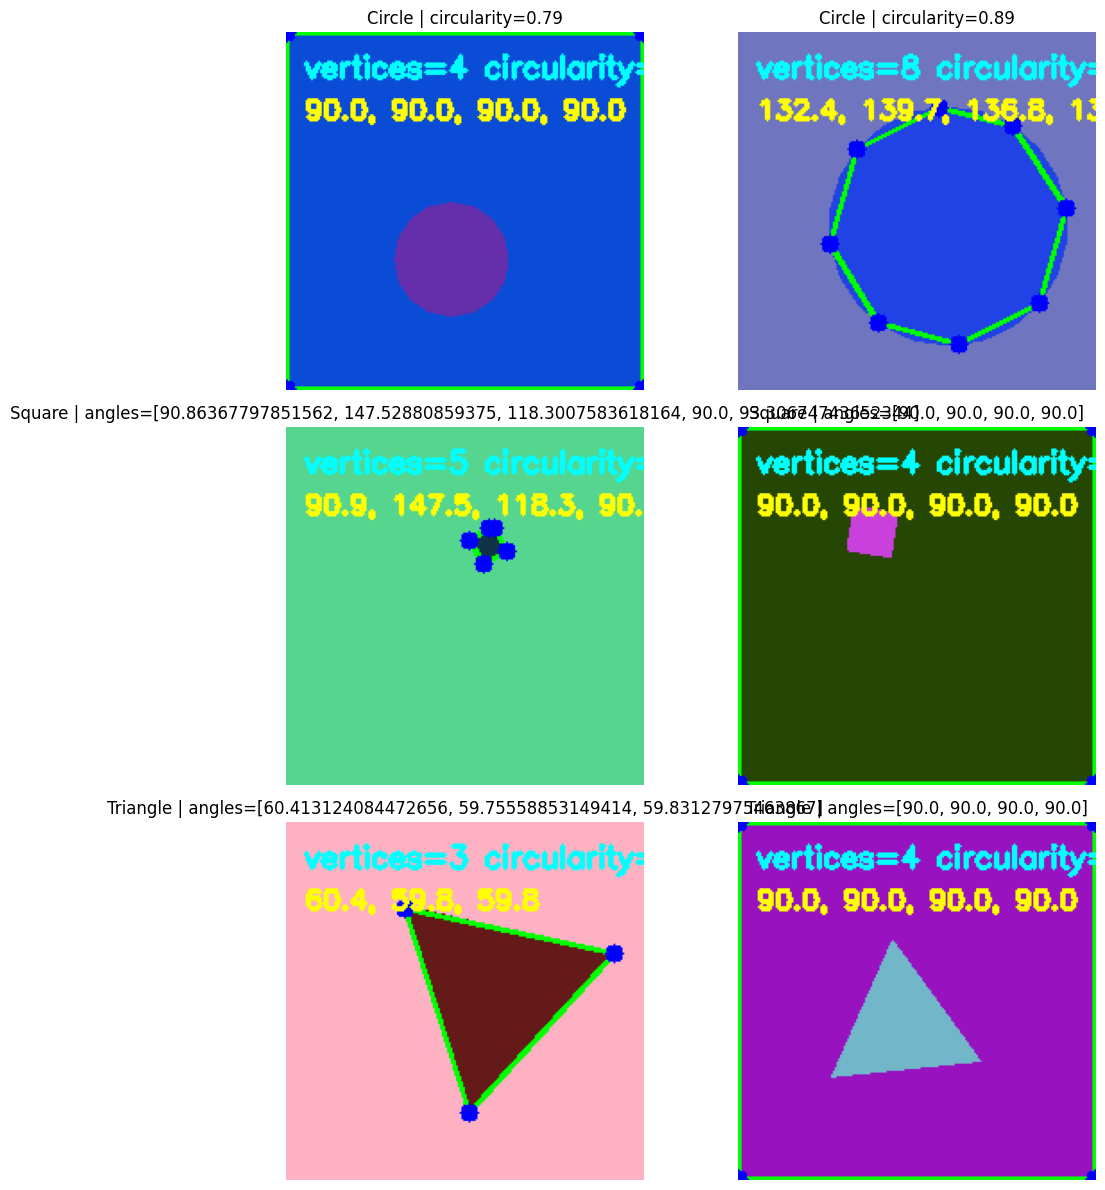

✓ Example plot saved to C:\Users\ahmad\real_time_angle_detector_project\outputs\angle_detector_examples.png


In [8]:
fig, axes = plt.subplots(len(EXPECTED_LABELS), 2, figsize=(10, 12))
for axis, result in zip(axes.flat, example_results):
    axis.imshow(result['annotated_rgb'])
    if result['label'] == 'Circle':
        title = f"{result['label']} | circularity={result['circularity']:.2f}"
    else:
        title = f"{result['label']} | angles={result['angles_deg']}"
    axis.set_title(title)
    axis.axis('off')

for axis in axes.flat[len(example_results):]:
    axis.axis('off')

plt.tight_layout()
examples_plot_path = OUTPUT_DIR / 'angle_detector_examples.png'
fig.savefig(examples_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\u2713 Example plot saved to {examples_plot_path}')

In [9]:
dataset_summary_path = OUTPUT_DIR / 'dataset_summary.csv'
analysis_csv_path = OUTPUT_DIR / 'angle_analysis.csv'
metrics_json_path = OUTPUT_DIR / 'metrics.json'
manifest_path = OUTPUT_DIR / 'project_manifest.json'

dataset_summary_df.to_csv(dataset_summary_path, index=False)
analysis_df.to_csv(analysis_csv_path, index=False)

metrics = {
    'project': 'Real Time Angle Detector',
    'dataset': {
        'name': 'Geometric Shapes Dataset',
        'source': 'https://www.kaggle.com/datasets/dineshpiyasamara/geometric-shapes-dataset',
        'root': str(dataset_dir),
        'labels': EXPECTED_LABELS,
        'split_note': 'Source dataset exposes labeled folders only; no train/validation/test split exists'
    },
    'analysis': {
        'max_images_per_class': MAX_IMAGES_PER_CLASS,
        'structure_match_rate_by_label': {row.label: float(row.structure_match_rate) for row in summary_df.itertuples()},
        'mean_angle_error_deg_by_label': {row.label: (None if pd.isna(row.mean_angle_error_deg) else float(row.mean_angle_error_deg)) for row in summary_df.itertuples()}
    },
    'qualitative_note': 'Circle images are handled as abstentions from polygon-angle claims; angle values are only reported when a polygon contour is recovered.'
}

manifest = {
    'dataset_summary_csv': str(dataset_summary_path),
    'analysis_csv': str(analysis_csv_path),
    'metrics_json': str(metrics_json_path),
    'dataset_overview_plot': str(dataset_overview_path),
    'metrics_plot': str(metrics_plot_path),
    'examples_plot': str(examples_plot_path)
}

metrics_json_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')

print(f'\u2713 Dataset summary saved to {dataset_summary_path}')
print(f'\u2713 Per-image analysis saved to {analysis_csv_path}')
print(f'\u2713 Metrics saved to {metrics_json_path}')
print(f'\u2713 Manifest saved to {manifest_path}')

✓ Dataset summary saved to C:\Users\ahmad\real_time_angle_detector_project\outputs\dataset_summary.csv
✓ Per-image analysis saved to C:\Users\ahmad\real_time_angle_detector_project\outputs\angle_analysis.csv
✓ Metrics saved to C:\Users\ahmad\real_time_angle_detector_project\outputs\metrics.json
✓ Manifest saved to C:\Users\ahmad\real_time_angle_detector_project\outputs\project_manifest.json


## Limitations And Honest Next Steps

- This notebook evaluates still images from a labeled shape dataset, not a webcam stream.
- The source data contains clean shapes, so it is useful for validating geometry logic but not for claiming production robustness under clutter, motion blur, or occlusion.
- A future real-time demo can reuse the same contour and angle functions on live frames after camera capture is added.